In [1]:
import numpy as np
import pandas as pd
import sweetviz as sv

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

C:\miniforge3\envs\machine-learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,400000,1,1,2,32,0,0,0,0,0,...,48272,49478,51242,3028,3023,3000,3000,3000,38662,0
1,120000,2,2,2,30,-1,-1,-1,-1,-1,...,1964,1883,1538,3230,3011,1964,1883,1538,1911,0
2,270000,2,2,2,32,0,0,0,0,0,...,94856,86461,83650,1808,69563,2891,2689,3012,2771,0
3,280000,2,2,1,27,0,0,0,0,0,...,257689,193231,191143,11052,9563,15017,5374,5420,6021,0
4,30000,2,1,2,27,0,0,-1,0,0,...,1814,0,0,1000,664,1500,0,0,0,0


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



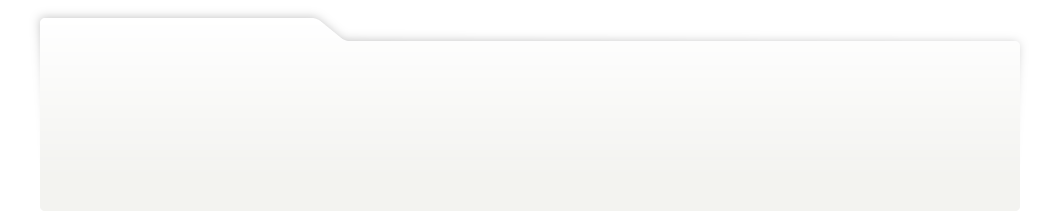
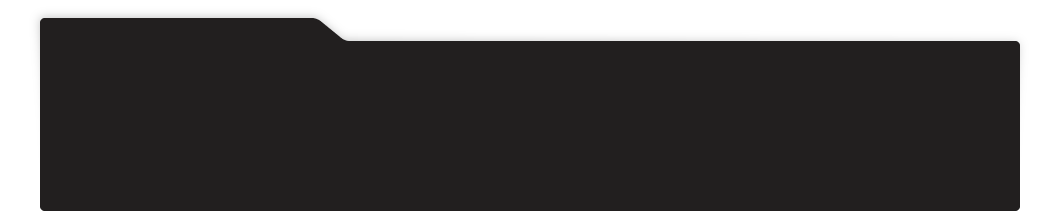
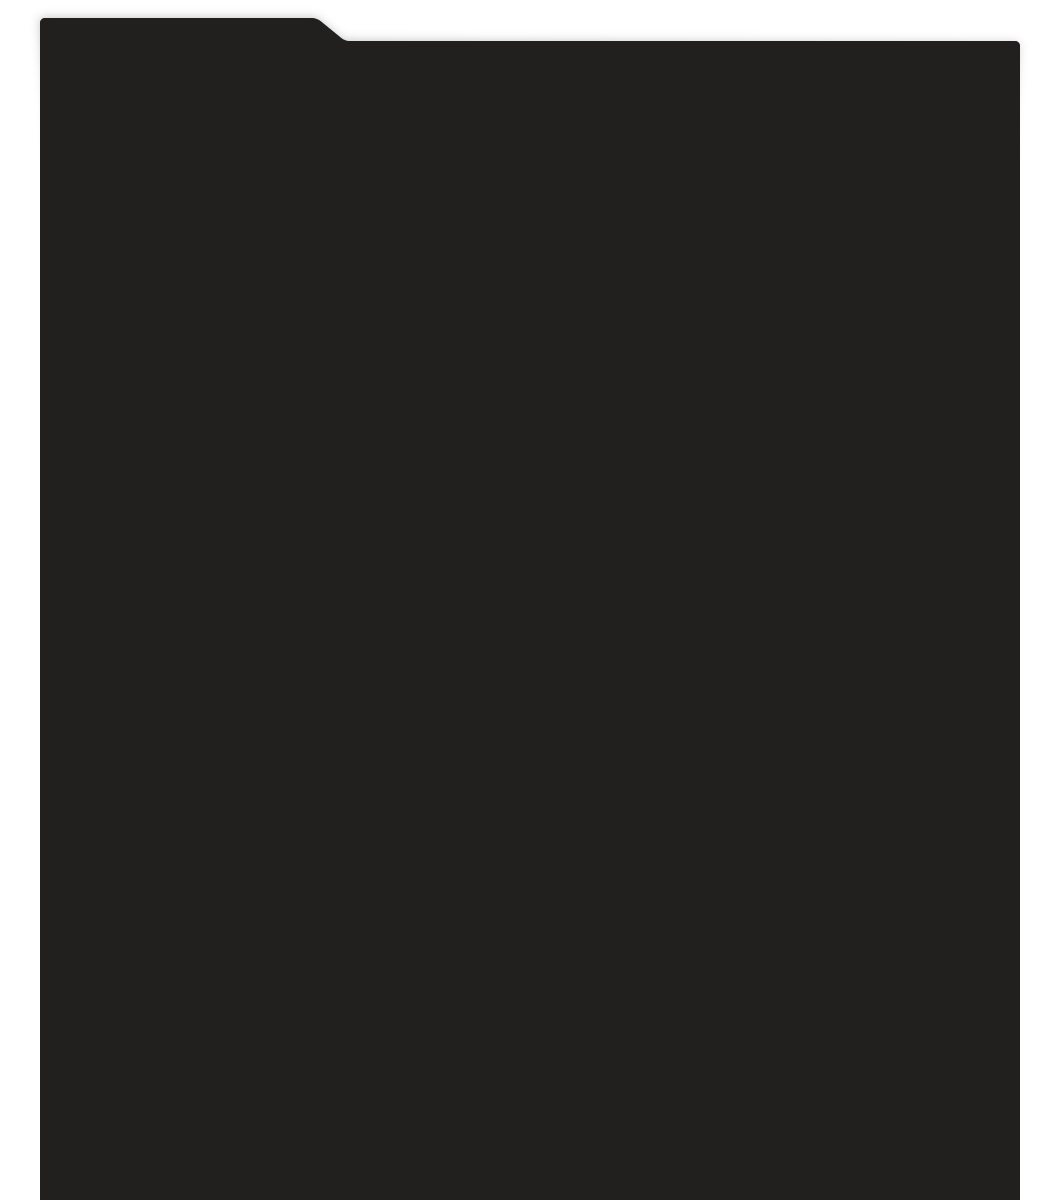
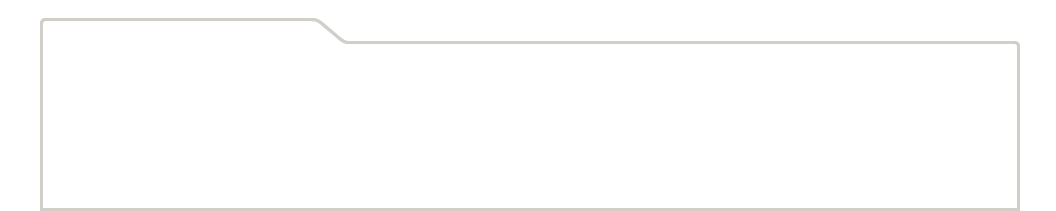
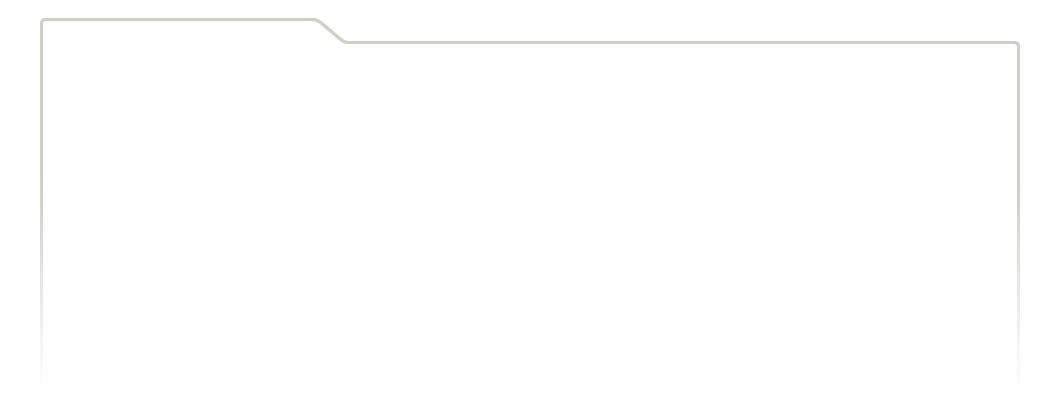
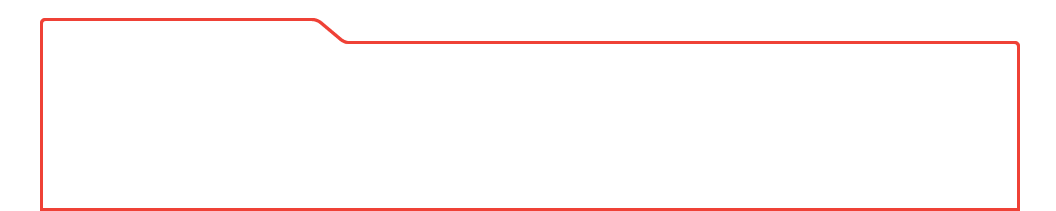
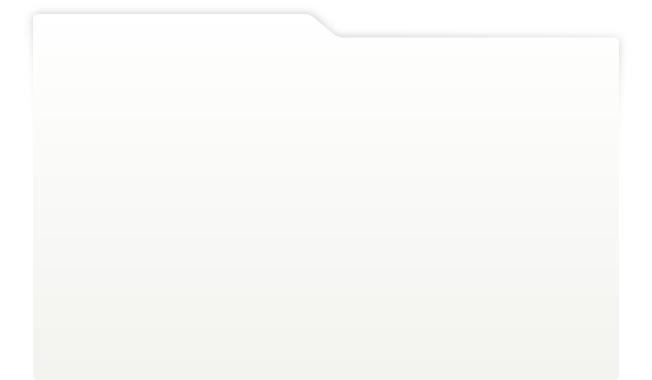
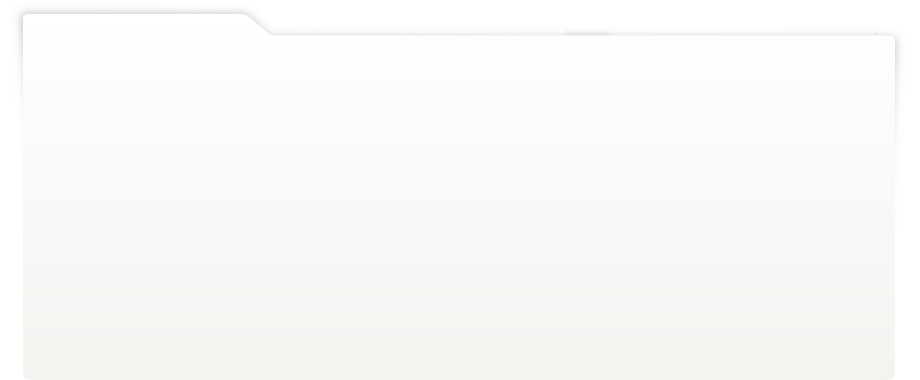
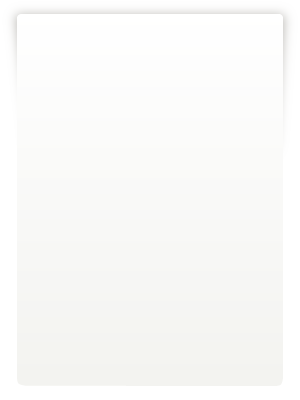
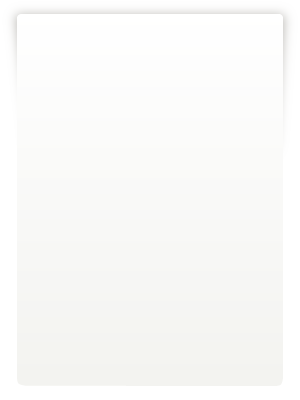
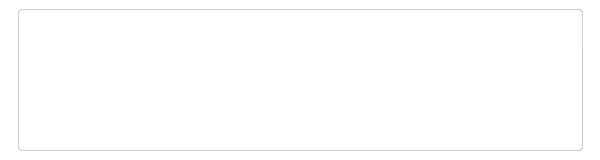
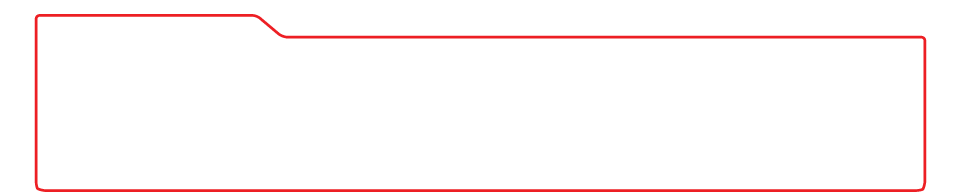
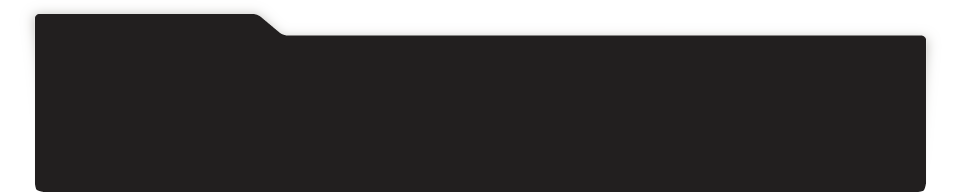
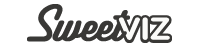
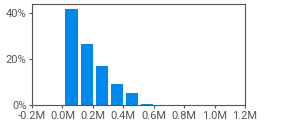
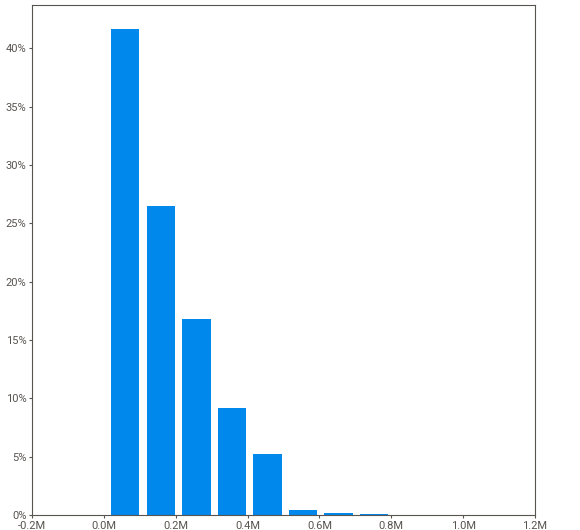
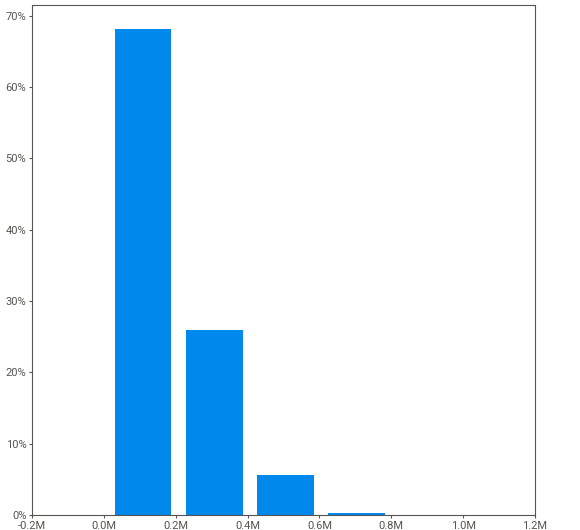
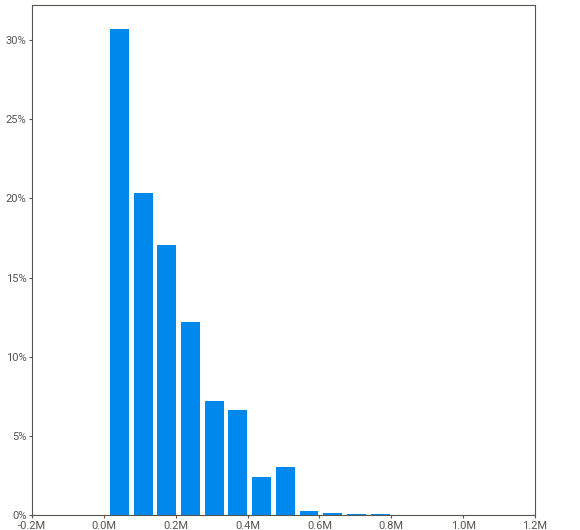
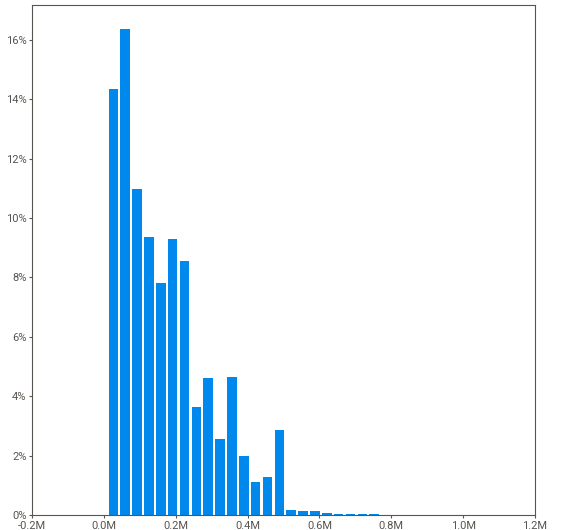
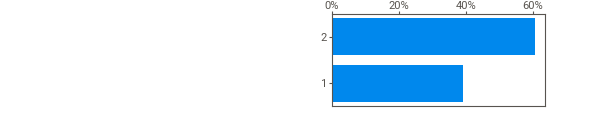
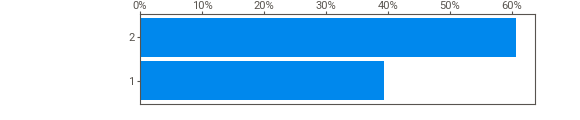
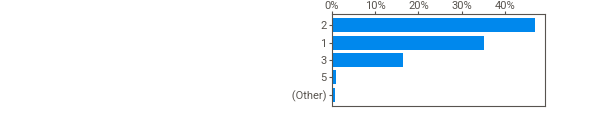
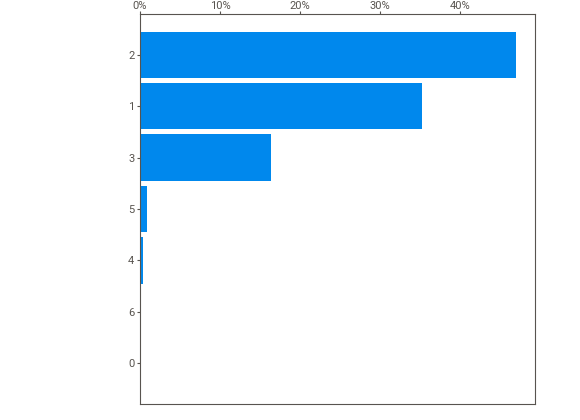
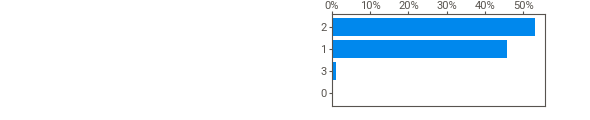
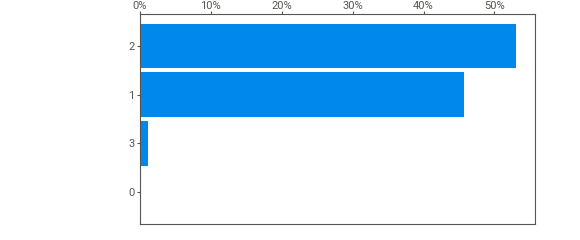
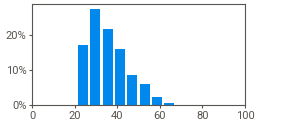
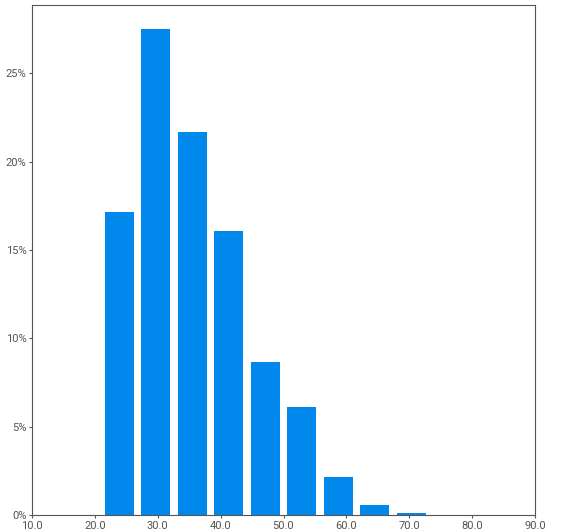
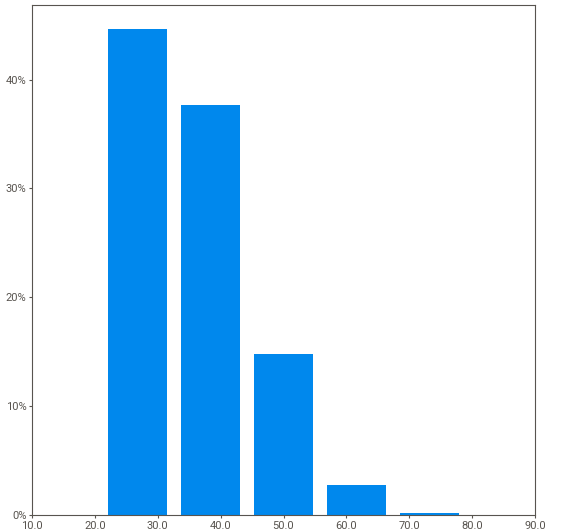
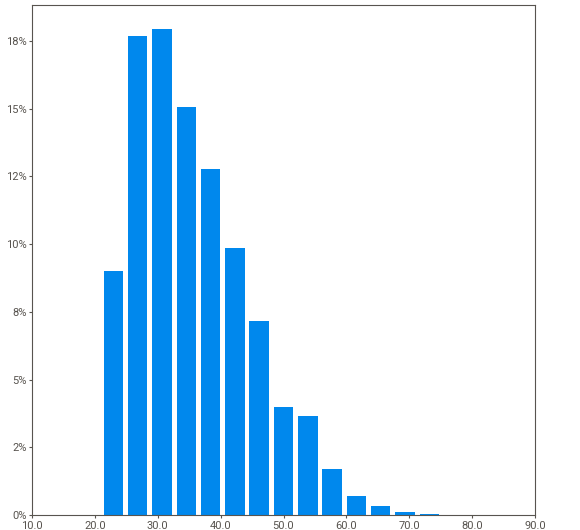
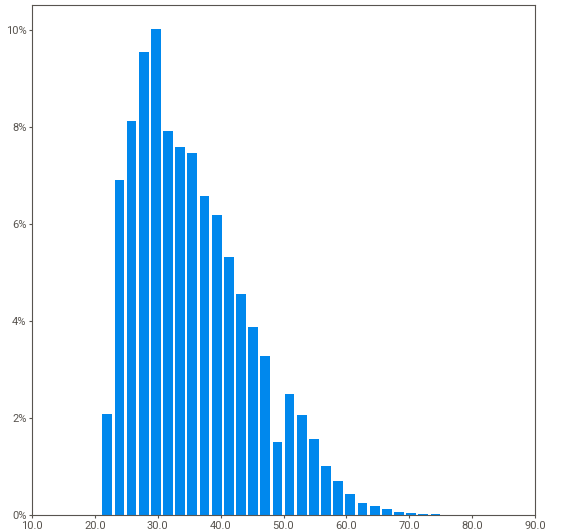
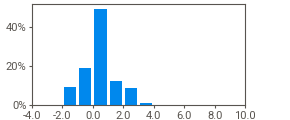
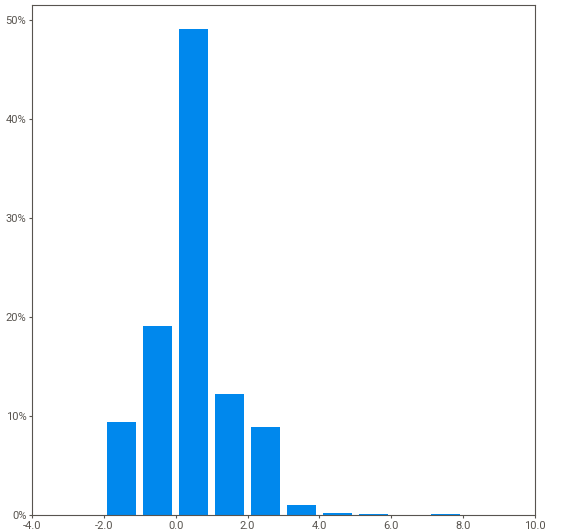
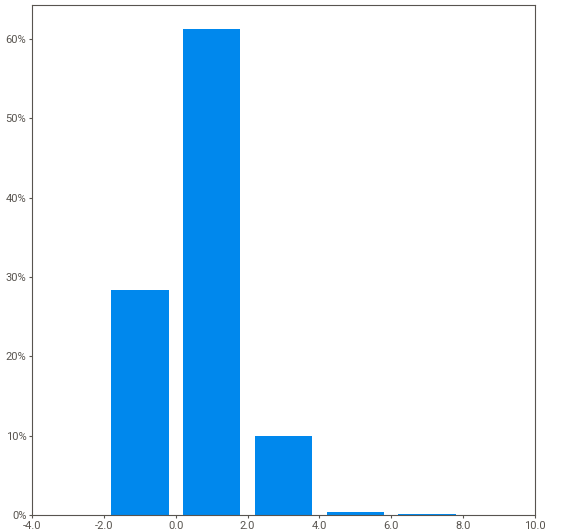
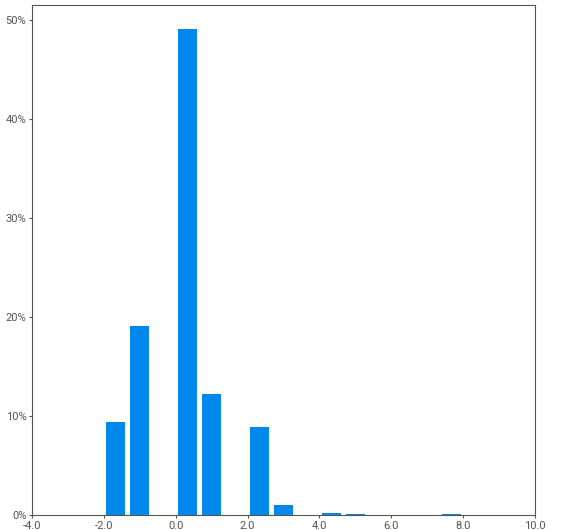
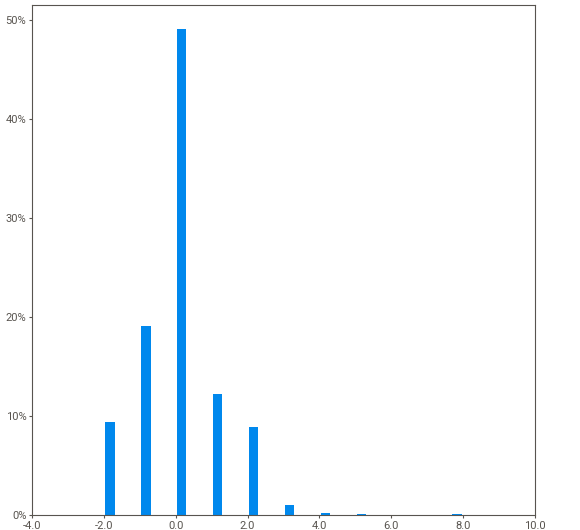
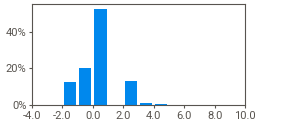
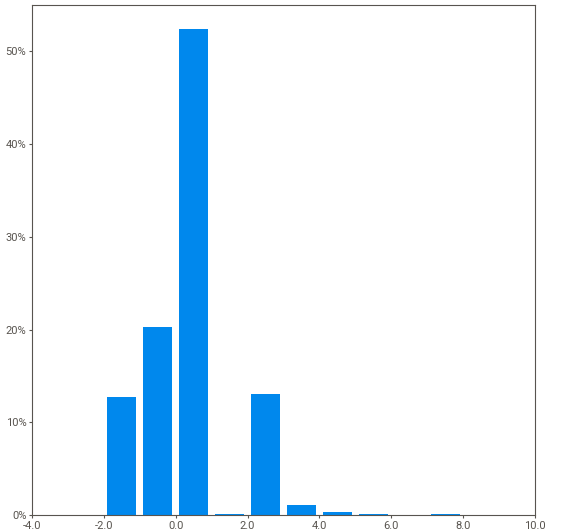
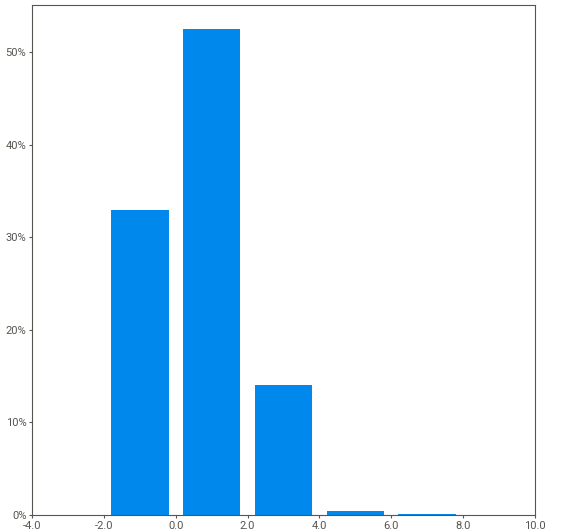
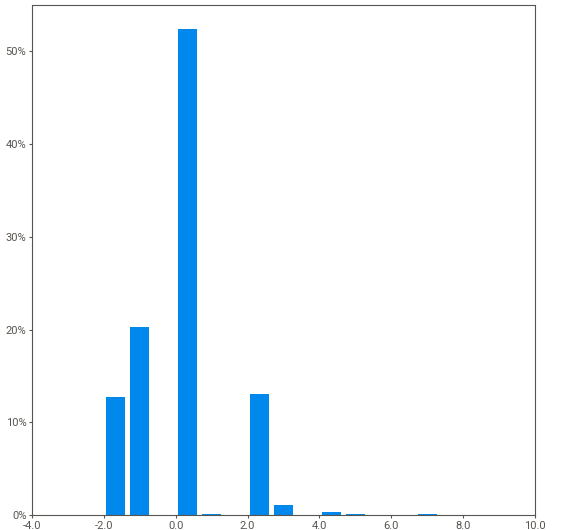
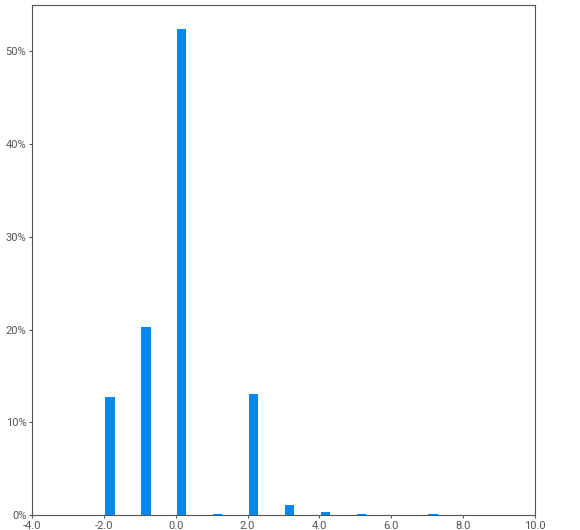
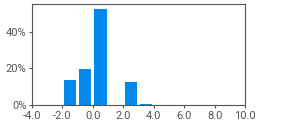
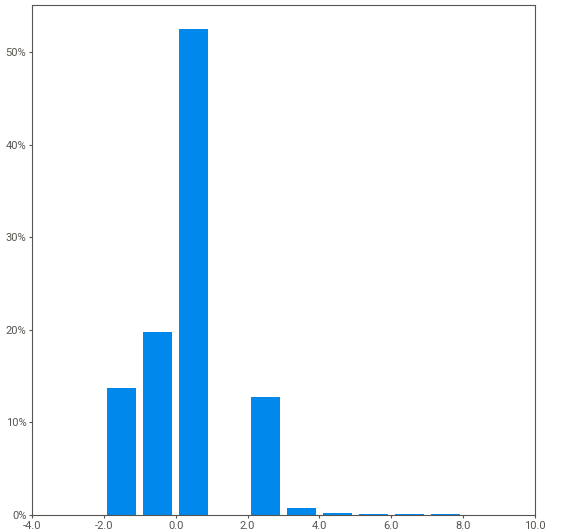
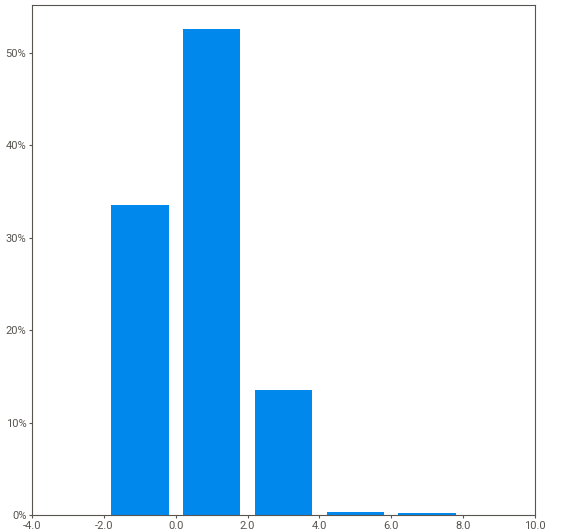
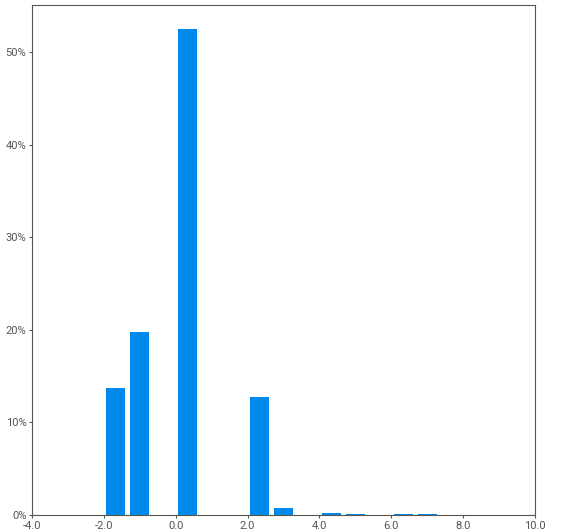
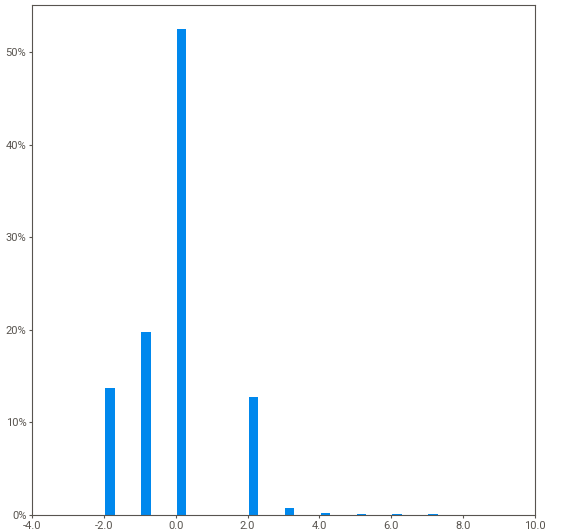
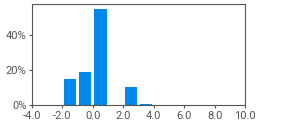
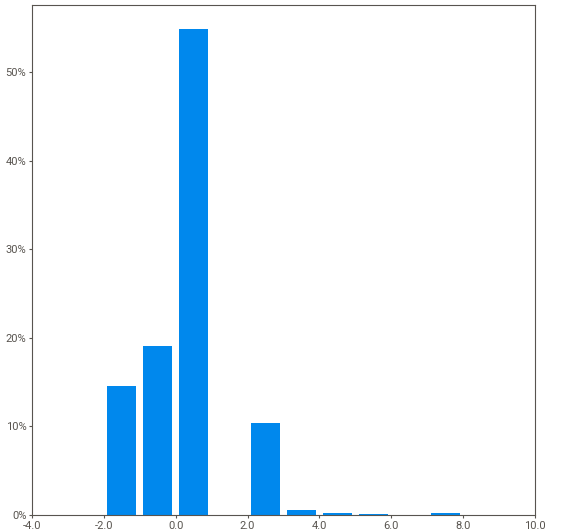
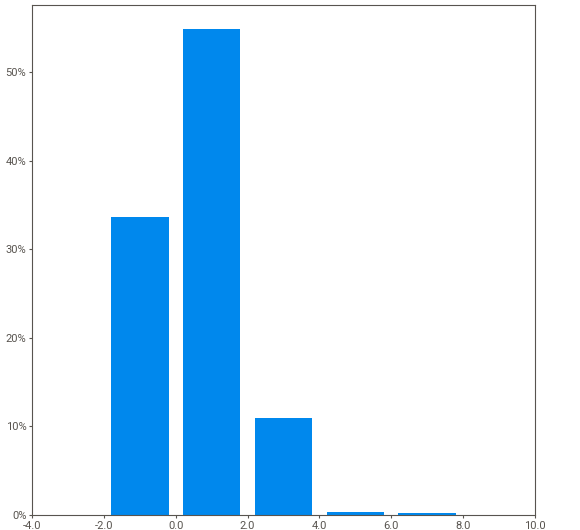
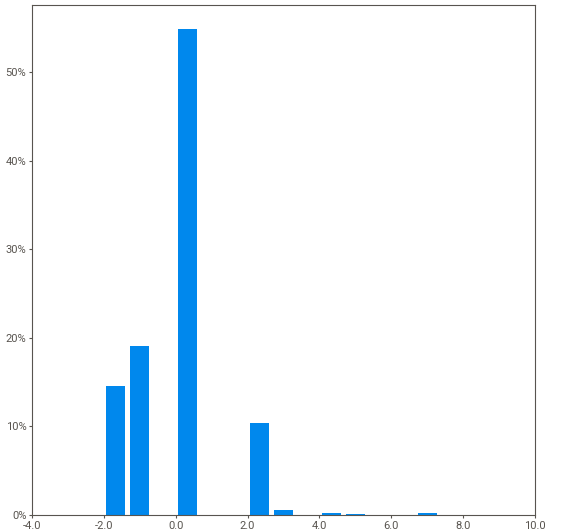
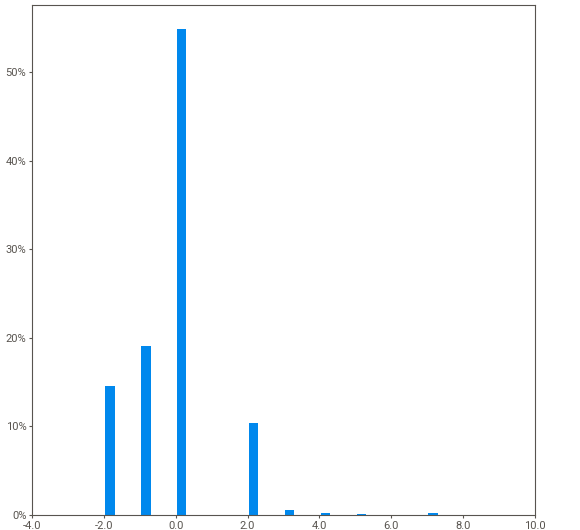
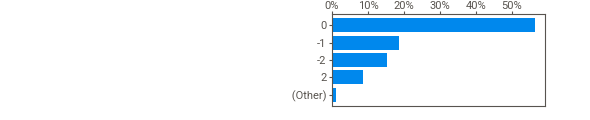
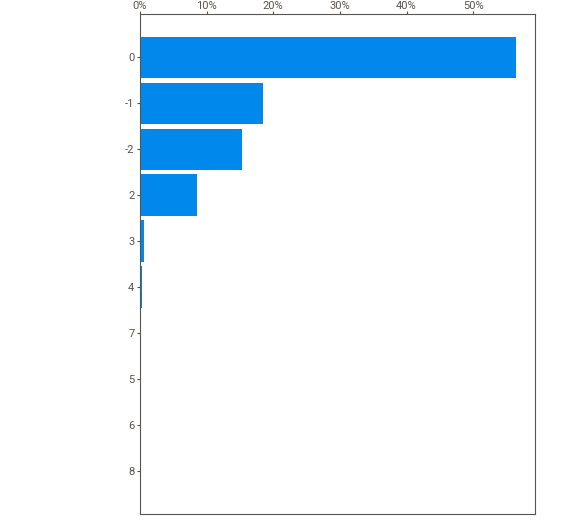
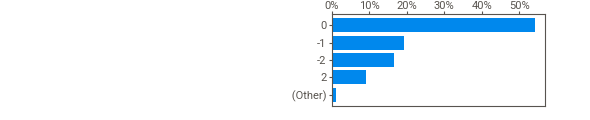
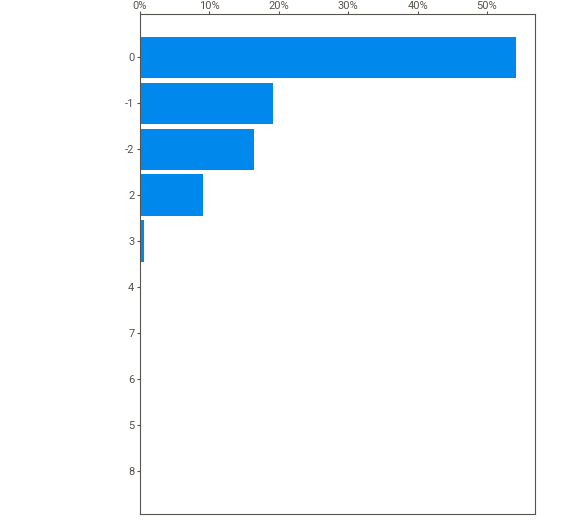
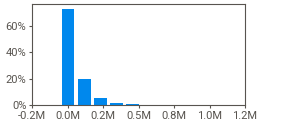
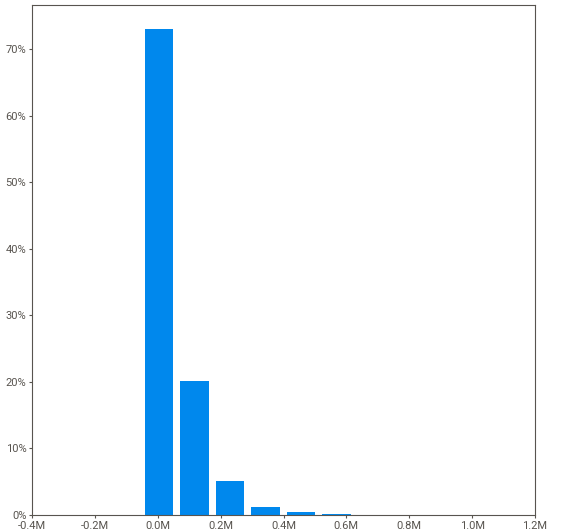
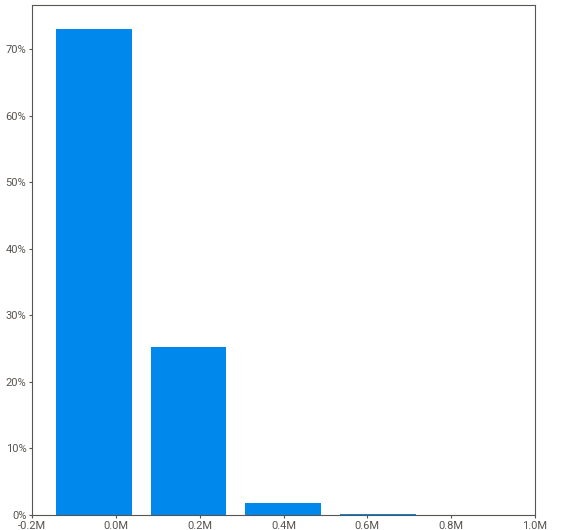
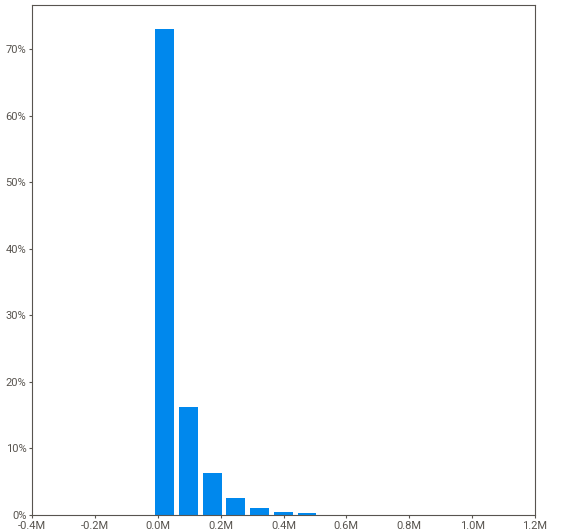
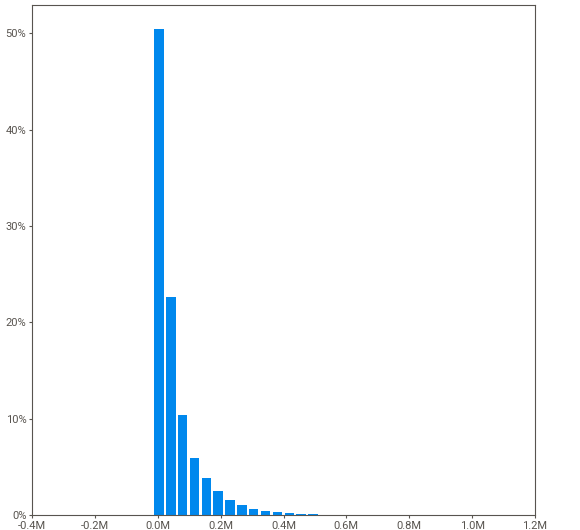
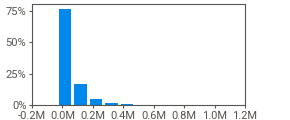
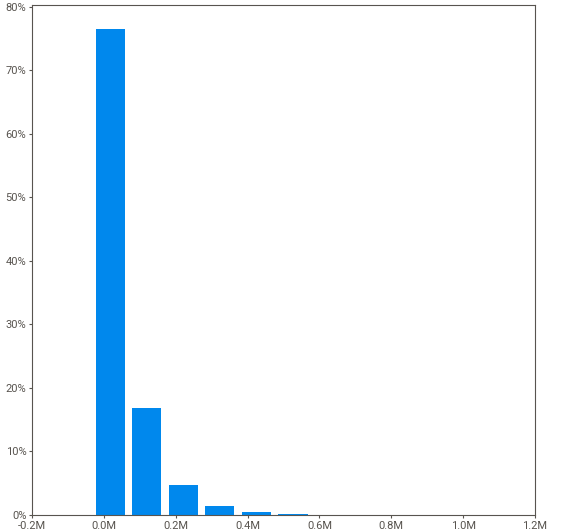
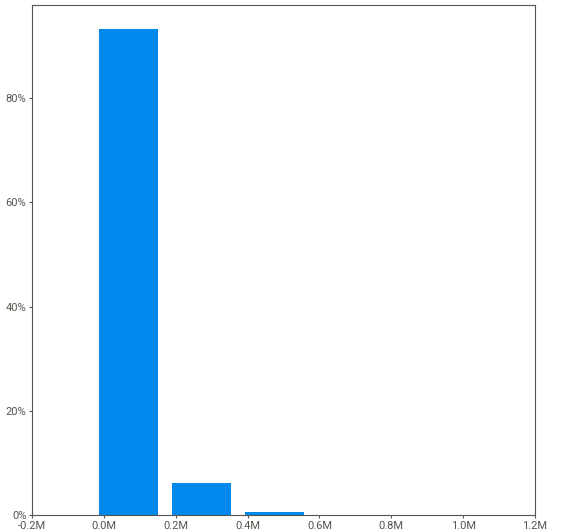
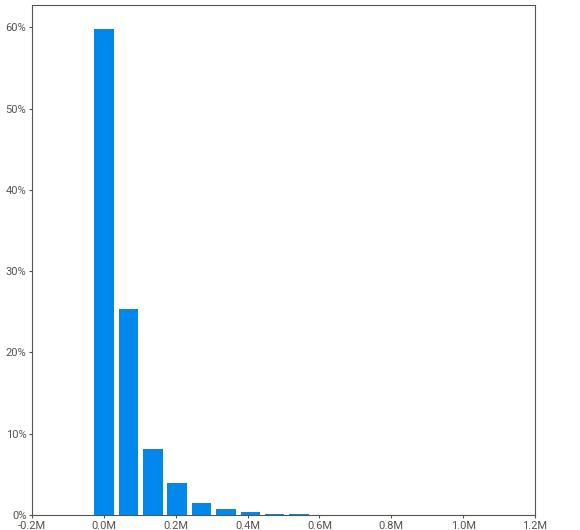
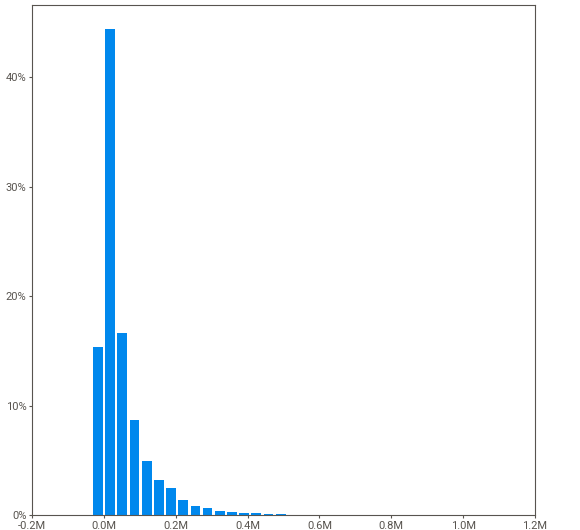
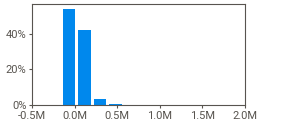
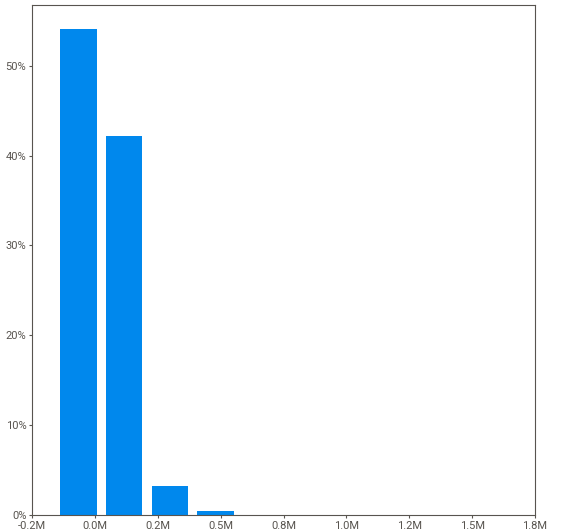
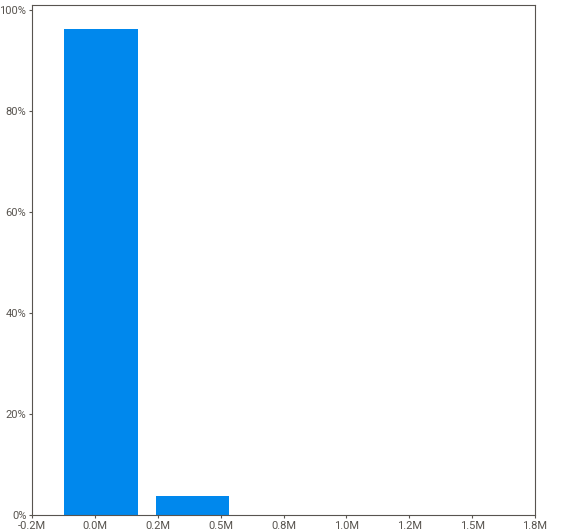
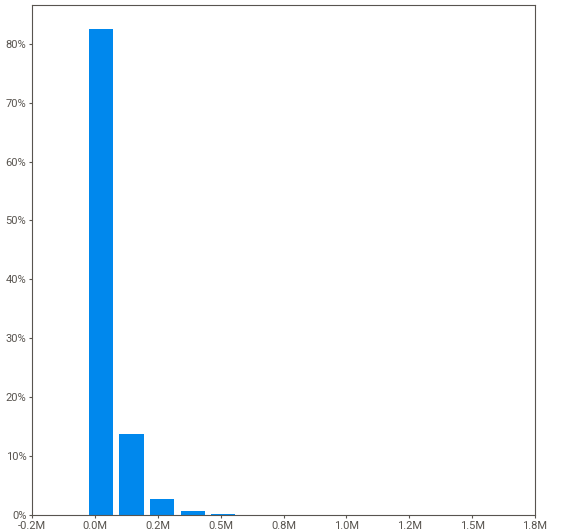
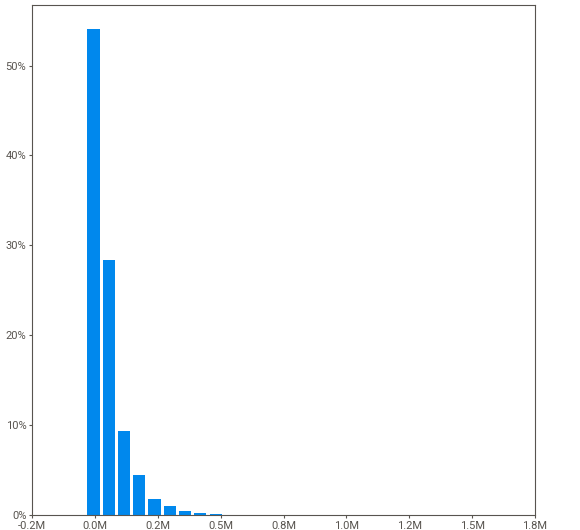
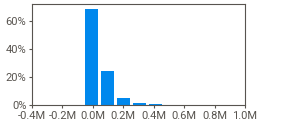
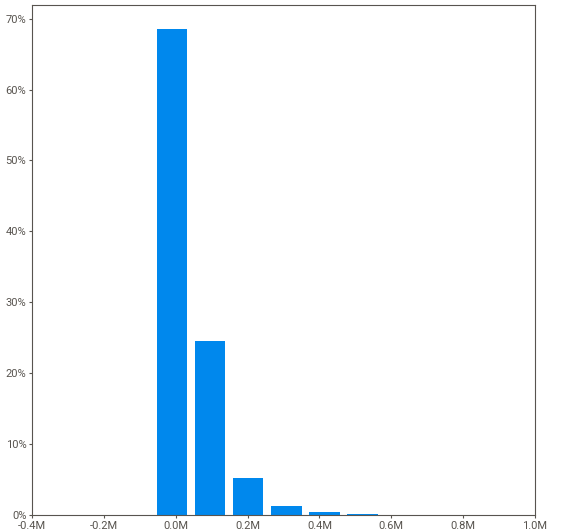
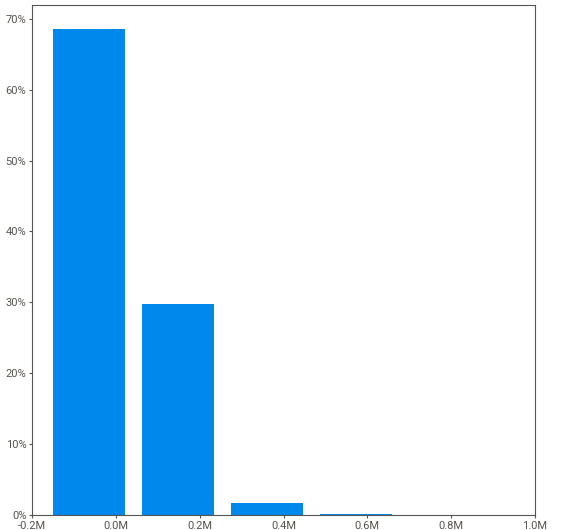
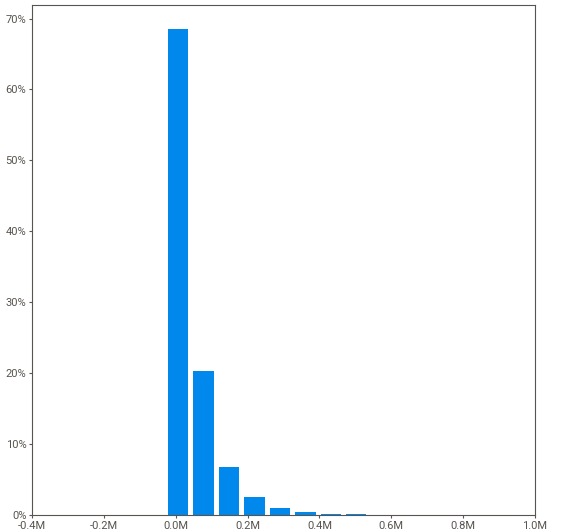
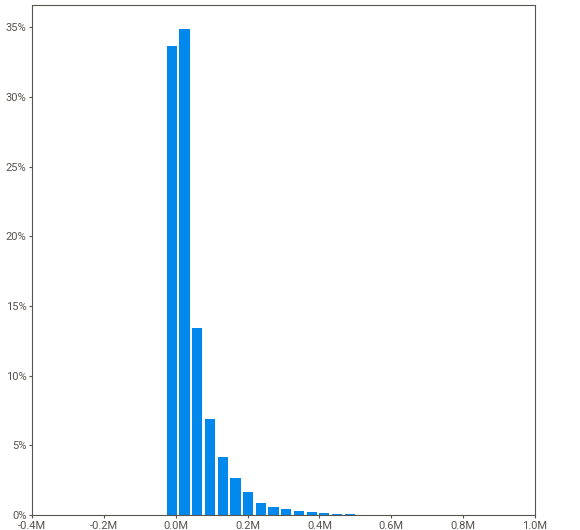
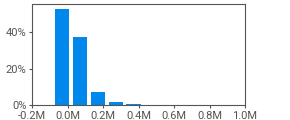
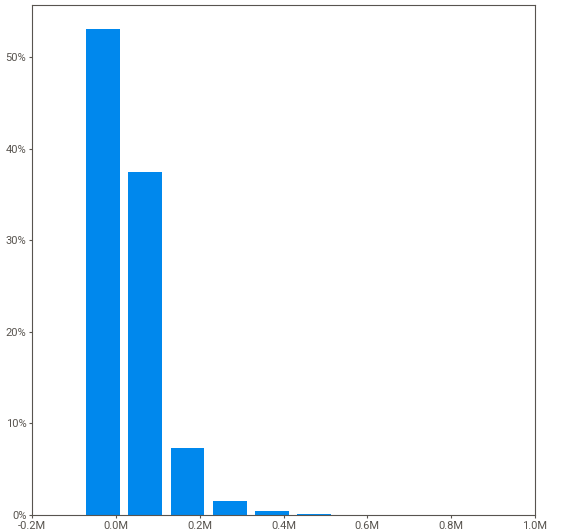
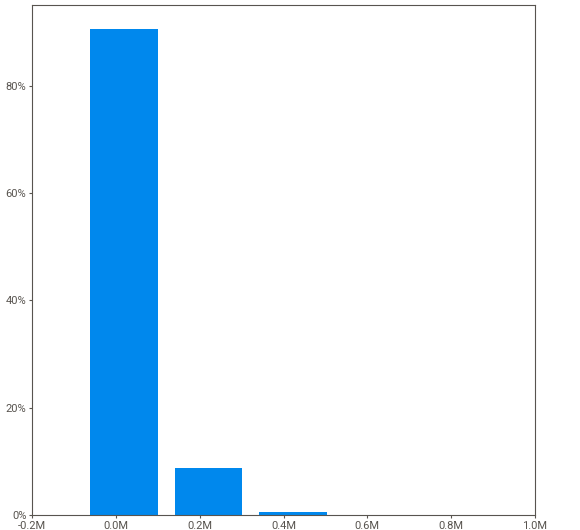
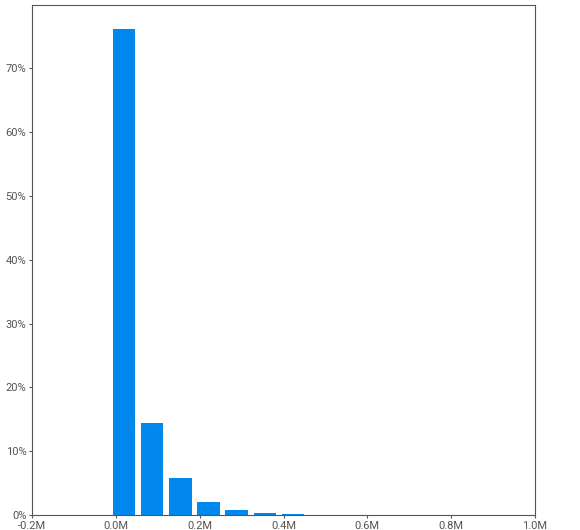
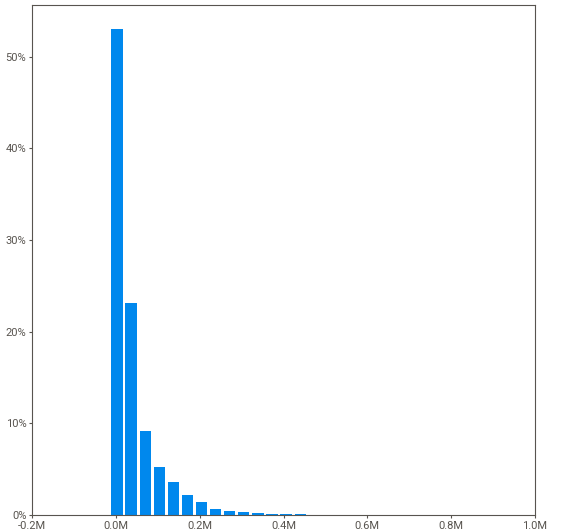
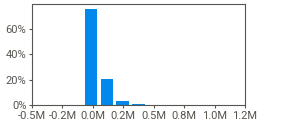
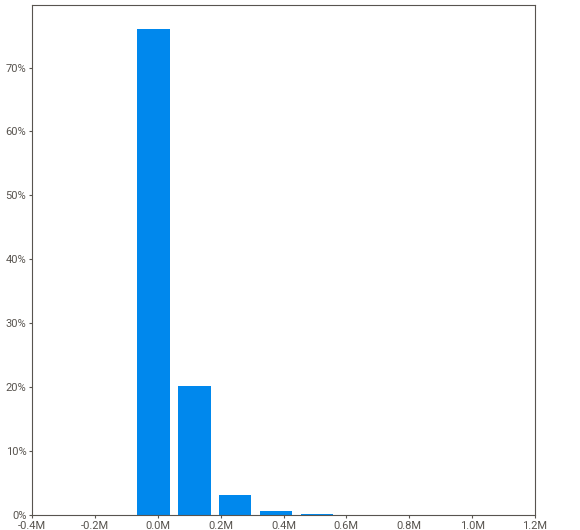
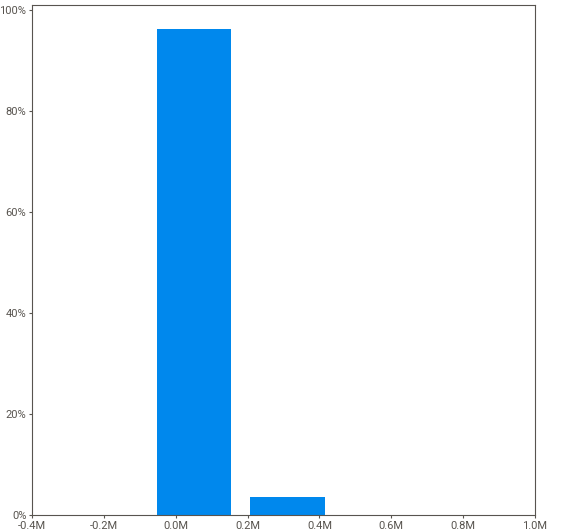
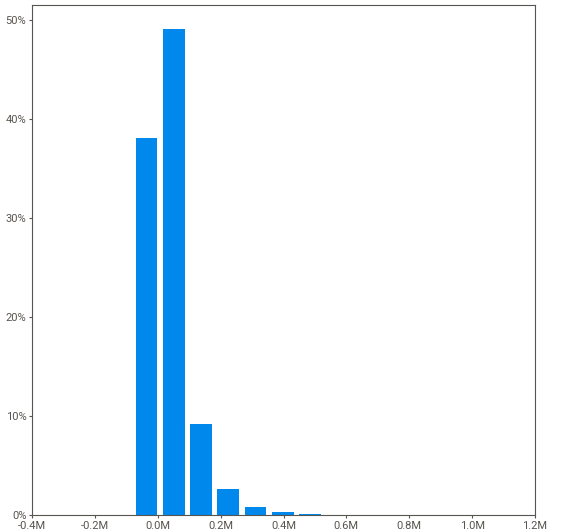
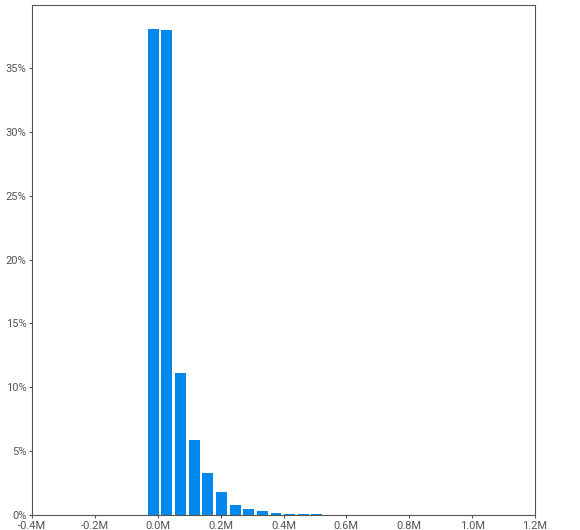
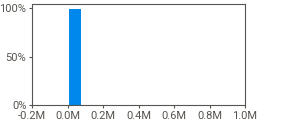
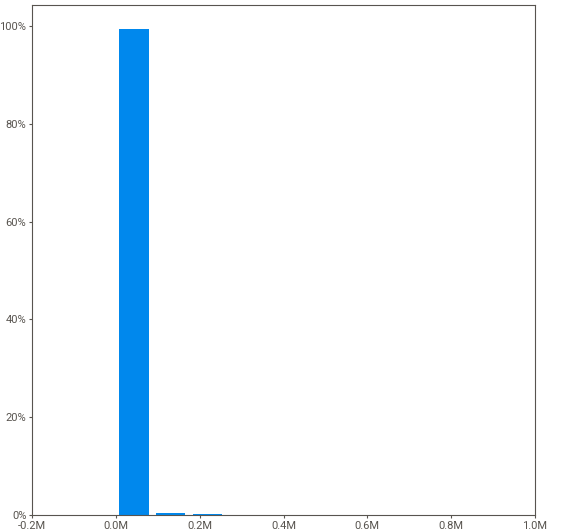
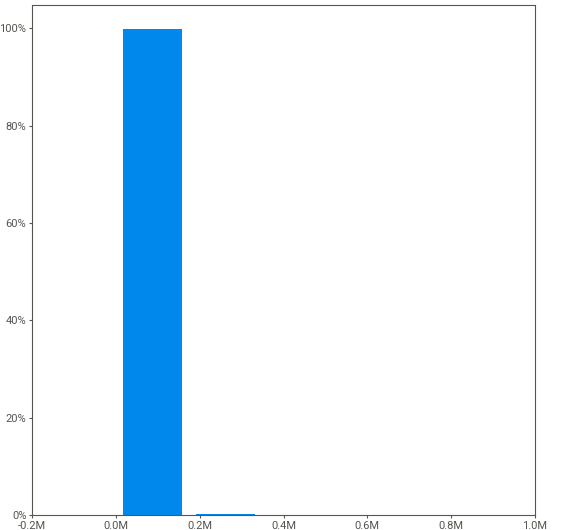
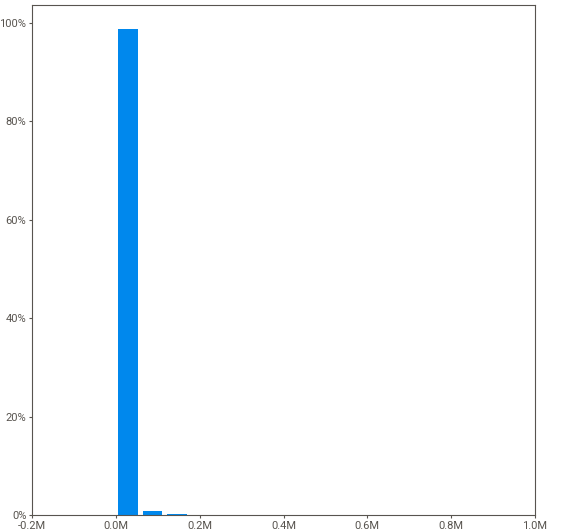
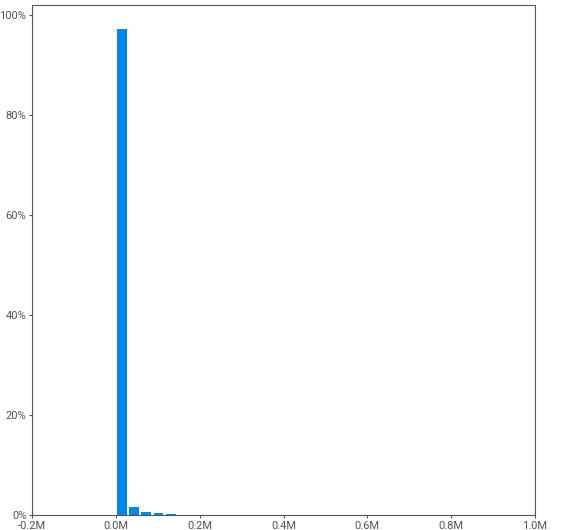
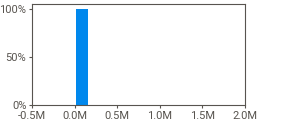
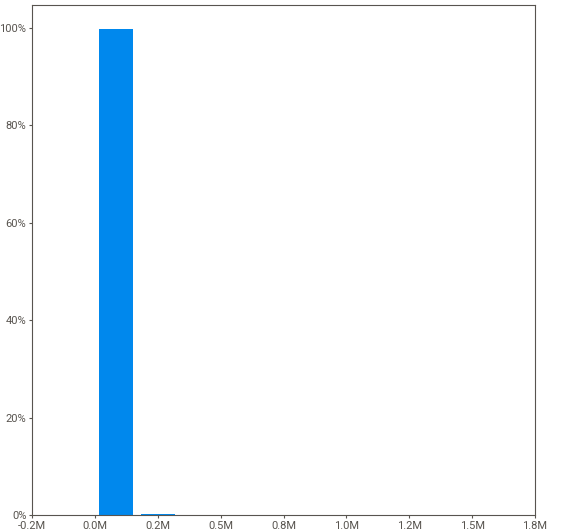
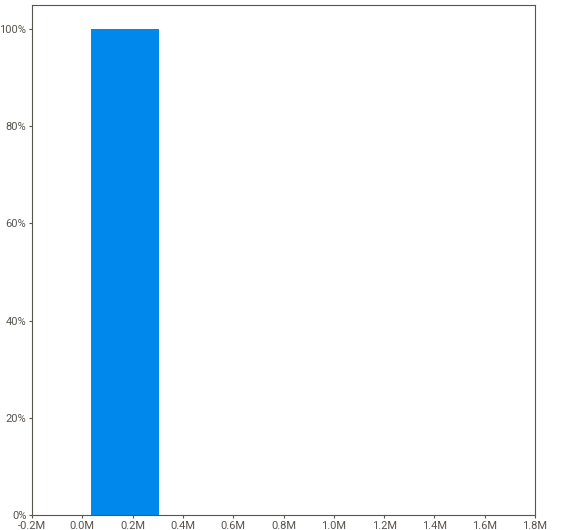
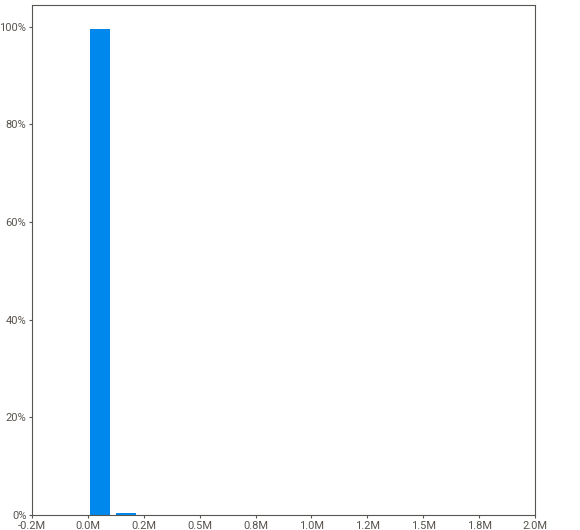
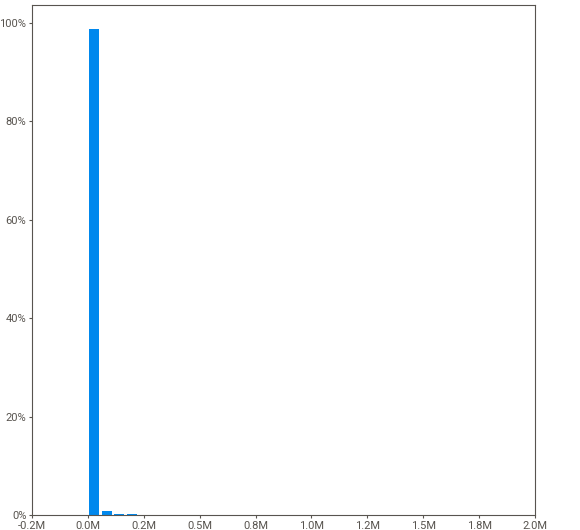
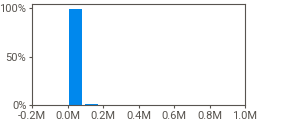
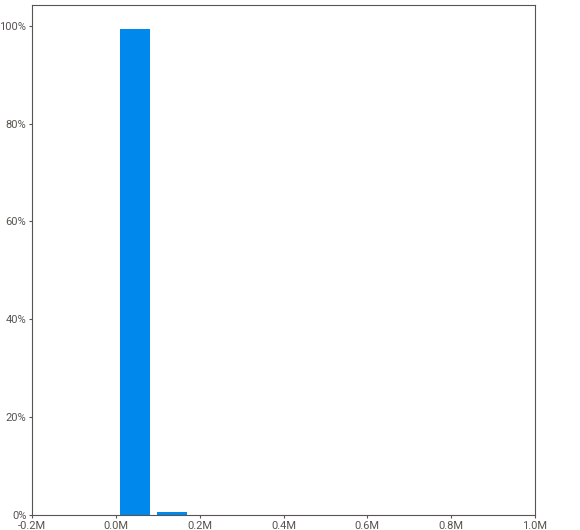
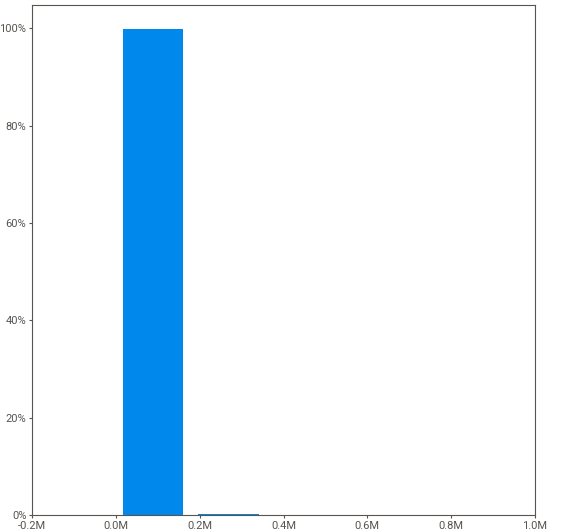
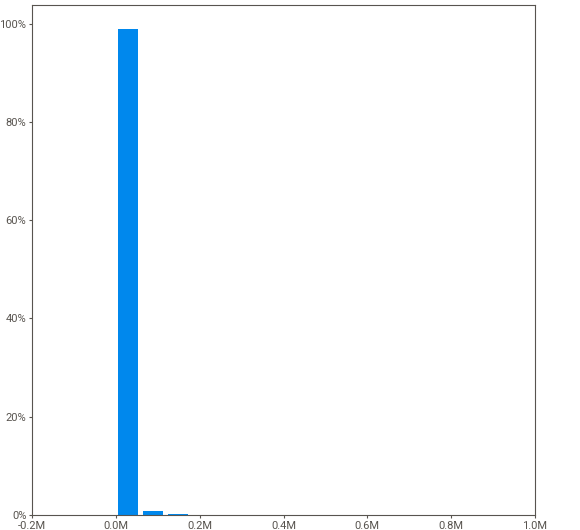
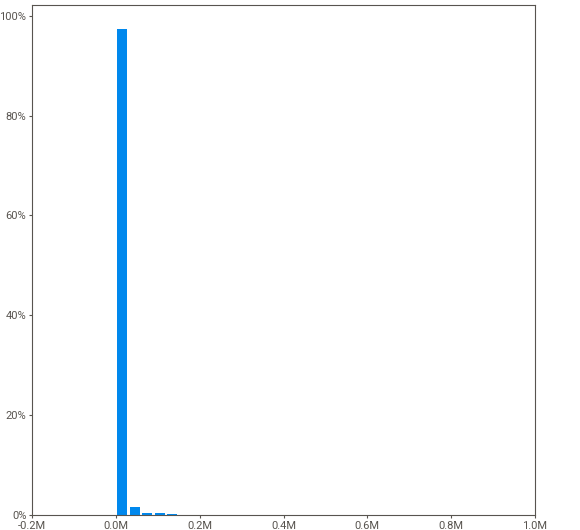
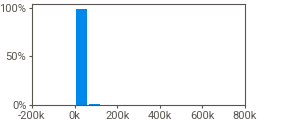
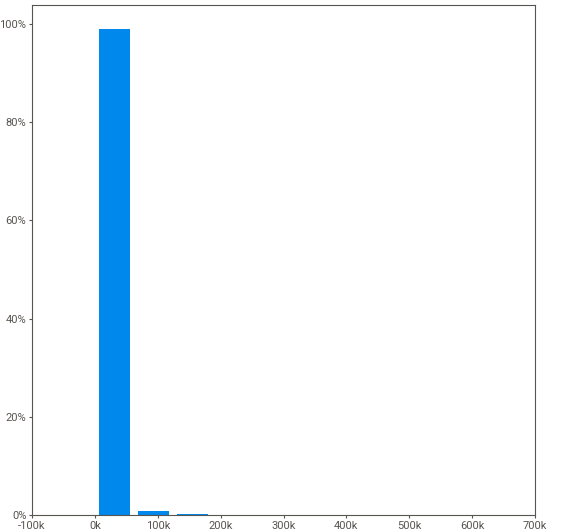
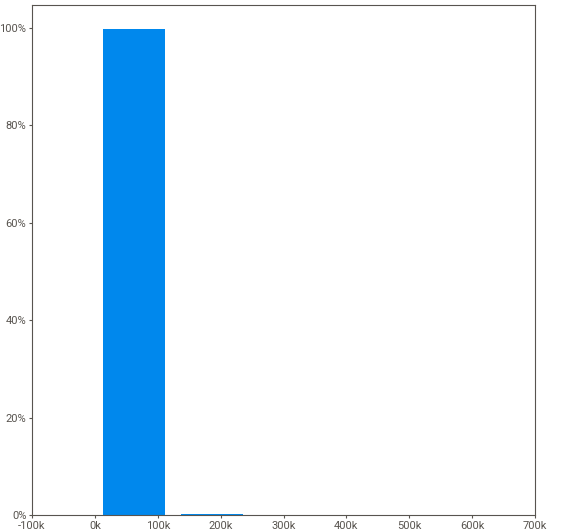
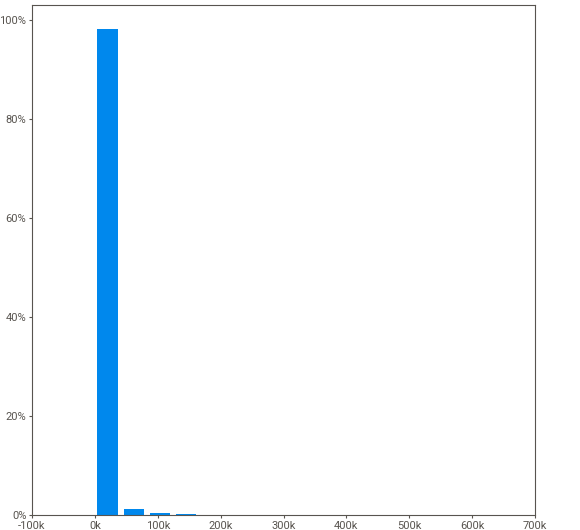
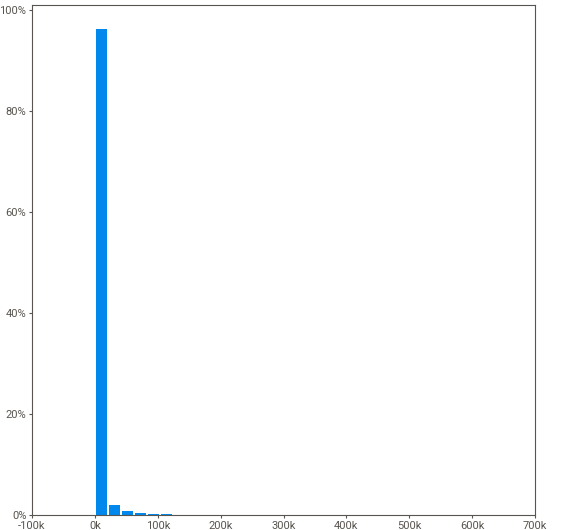
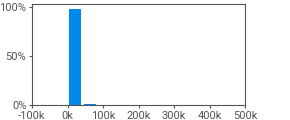
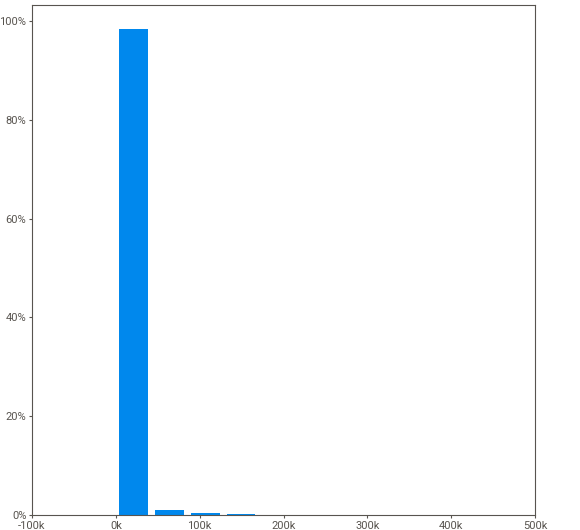
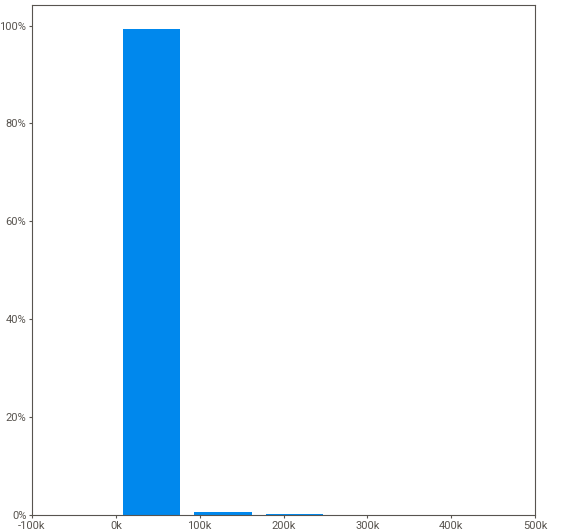
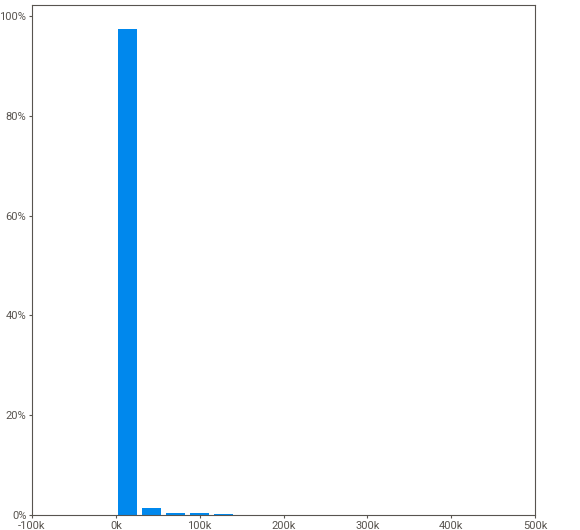
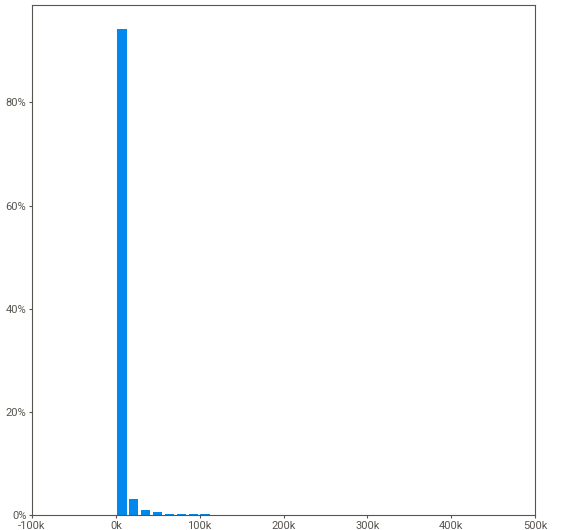
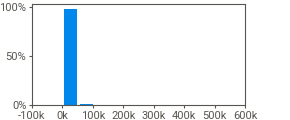
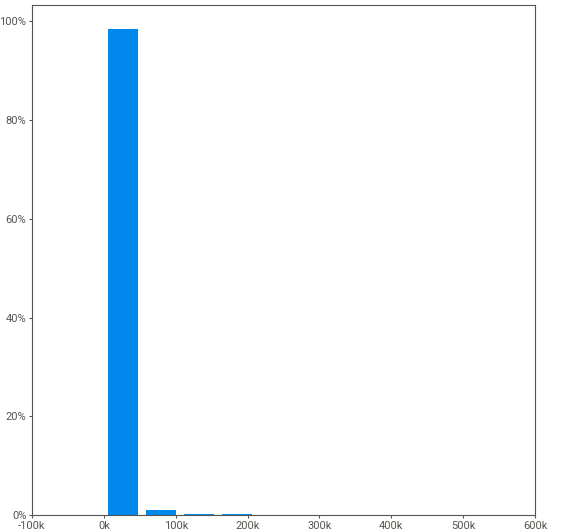
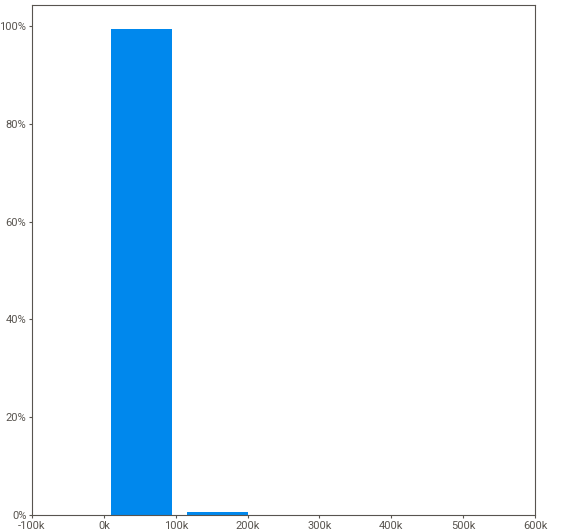
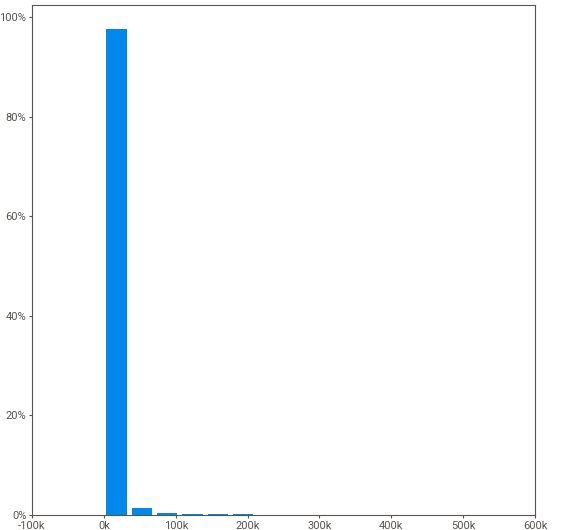
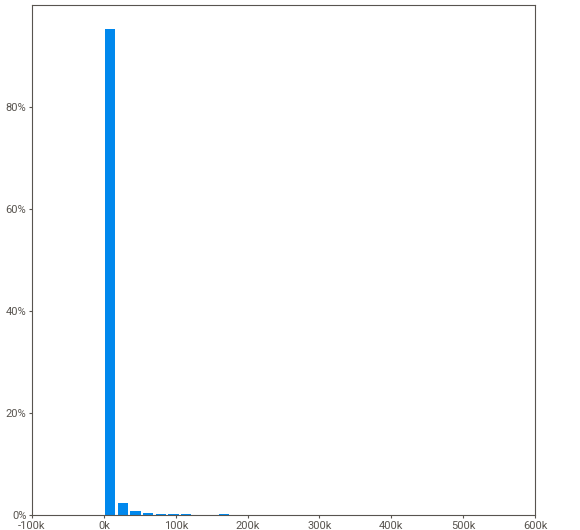
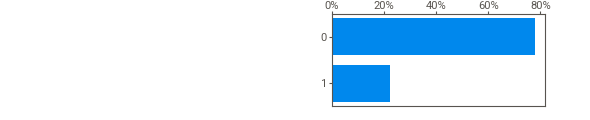
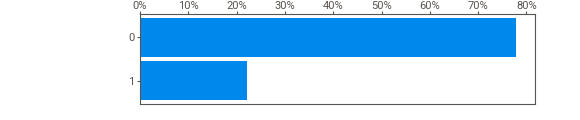
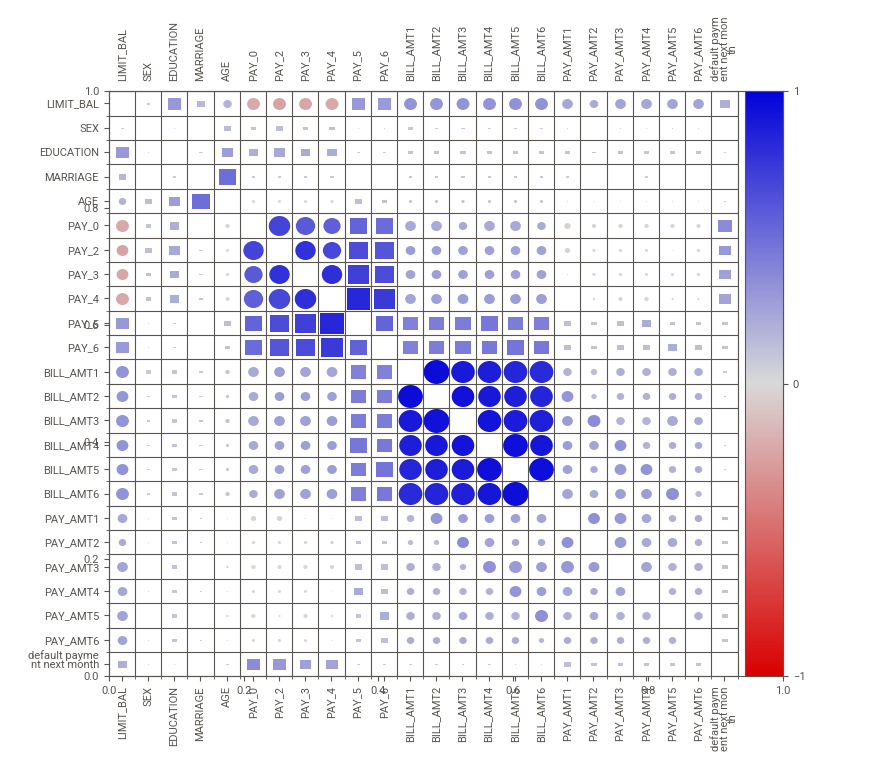
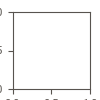

In [3]:
report = sv.analyze(df)
report.show_notebook()

looks like the `PAY_N` variables have decent associations with our outcome. same goes with `LIMIT_BAL`

In [4]:
X = df.drop(columns=["default payment next month"])
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y,
                                                    shuffle=True
                                                    )

In [5]:
# base rf
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3738
           1       0.62      0.38      0.47      1062

    accuracy                           0.81      4800
   macro avg       0.73      0.66      0.68      4800
weighted avg       0.79      0.81      0.79      4800



In [6]:
rf_cv_score = cross_val_score(rf, X, y, cv=5, scoring="precision_macro")
rf_cv_std = np.std(rf_cv_score)
rf_cv_mean = rf_cv_score.mean()

(rf_cv_mean, rf_cv_std)

(np.float64(0.7396693857033385), np.float64(0.008014681809449658))

In [7]:
# base xgb
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      3738
           1       0.61      0.38      0.47      1062

    accuracy                           0.81      4800
   macro avg       0.73      0.66      0.68      4800
weighted avg       0.79      0.81      0.79      4800



In [8]:
xgb_cv_score = cross_val_score(xgb, X, y, cv=5, scoring="precision_macro")
xgb_cv_std = np.std(xgb_cv_score)
xgb_cv_mean = xgb_cv_score.mean()

(xgb_cv_mean, xgb_cv_std)

(np.float64(0.7358942529775573), np.float64(0.008470344323085697))

## model cv results discussion

*how did models perform?*

- base random forest outperformed the base xgboost. both models cleary are affected by the class imbalance, as indicated by their poor class 1 recall scores.

*what does mean and stdev of folds tell us?*

- i used `precision_macro` because it is ideal for imbalanced datasets where we care about the minority class.
- a very small standard deviation tells us the makeup of each split has little effect on model performance.

*look at the `classification_report` for both models, does this change your evaluation of the models?*

- no. it reinforces the cross-val scores: the minority class performance is more of a poor-formance.

In [20]:
# hyper tuning rf
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"],
    "n_jobs": [-1], # use all cores!!
}

rf_gscv = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="precision_macro",
    verbose=1
)

rf_gscv.fit(X_train, y_train)
rf_gscv_pred = rf_gscv.best_estimator_.predict(X_test)

print(classification_report(y_test, rf_gscv_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3738
           1       0.64      0.36      0.46      1062

    accuracy                           0.81      4800
   macro avg       0.74      0.65      0.67      4800
weighted avg       0.79      0.81      0.79      4800



In [24]:
# hyper tuning xgb
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "learning_rate": np.arange(0.2, 0.5, 0.1),
    "gamma": np.arange(0, 0.5, 0.1),
    "lambda": [0, 1, 2],
}

xgb_gscv = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="precision_macro",
    verbose=1
)

xgb_gscv.fit(X_train, y_train)
xgb_gscv_pred = xgb_gscv.best_estimator_.predict(X_test)

print(classification_report(y_test, xgb_gscv_pred))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3738
           1       0.64      0.38      0.47      1062

    accuracy                           0.81      4800
   macro avg       0.74      0.66      0.68      4800
weighted avg       0.80      0.81      0.80      4800



In [33]:
# try using bootstrapping
final_params = xgb_gscv.best_params_
final_params["subsample"] = 0.8

final_xgb = XGBClassifier(**final_params)
final_xgb.fit(X_train, y_train)

final_xgb_pred = final_xgb.predict(X_test)

print(classification_report(y_test, final_xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3738
           1       0.63      0.39      0.48      1062

    accuracy                           0.81      4800
   macro avg       0.74      0.66      0.68      4800
weighted avg       0.80      0.81      0.80      4800



In [34]:
# real, although marginal, performance increases
cross_val_score(final_xgb, X, y, cv=5, scoring="precision_macro")

array([0.73382717, 0.73850997, 0.74086154, 0.74331381, 0.75025403])

*with tuning, how did performance change?*

- performance slightly increased across both models...where they perform almost exactly the same.
- i think i chose the right parameters, however the real issue is that we do not have any engineered features and have inter-feature correlation.

*which of your models was better out of the box?*

- the random forest model was slightly better, with a marginal gain in `precision_micro`. in practice, i think both out-of-the-box models were virtually the same for this dataset.